In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

nadlan_df = pd.read_excel('nadlan.xlsx')

In [2]:
nadlan_df.columns

Index(['year_month', 'year_quarter', 'year', 'month', 'quarter',
       'boi_interest_rate', 'tus', 'tus_seasonal_cleaned', 'tus_trend', 'nus',
       'nus_seasonal_cleand', 'nus_trend', 'ous', 'ous_seasonal_cleaned',
       'ous_trend', 'unsold_units_supply', 'uus_seasonal_cleaned', 'uus_trend',
       'jerusalem_tus', 'jerusalem_nus', 'jerusalem_ous', 'north_tus',
       'north_nus', 'north_ous', 'haifa_tus', 'haifa_nus', 'haifa_ous',
       'central_tus', 'central_nus', 'central_ous', 'tlv_tus', 'tlv_nus',
       'tlv_ous', 'south_tus', 'south_nus', 'south_ous', 'judea_samaria_tus',
       'judea_samaria_nus', 'judea_samaria_ous'],
      dtype='object')

### Quarterly Transactions Overview

In [3]:
list_of_vars = ['year_quarter',
        'tus', 'tus_seasonal_cleaned', 'tus_trend', 'nus',
       'nus_seasonal_cleand', 'nus_trend', 'ous', 'ous_seasonal_cleaned',
       'ous_trend', 'unsold_units_supply', 'uus_seasonal_cleaned', 'uus_trend',
       'jerusalem_tus', 'jerusalem_nus', 'jerusalem_ous', 'north_tus',
       'north_nus', 'north_ous', 'haifa_tus', 'haifa_nus', 'haifa_ous',
       'central_tus', 'central_nus', 'central_ous', 'tlv_tus', 'tlv_nus',
       'tlv_ous', 'south_tus', 'south_nus', 'south_ous', 'judea_samaria_tus',
       'judea_samaria_nus', 'judea_samaria_ous']

quarterly_df  = nadlan_df[list_of_vars].groupby(by=['year_quarter'],as_index=False).sum().head(20)
quarterly_df.head(2)



rates = nadlan_df[['year_quarter','boi_interest_rate']].groupby(by=['year_quarter'],as_index=False).mean().head(14)
quarterly_df = pd.merge(rates, quarterly_df, on='year_quarter', how='left')

# remove second quarter for 2025 since its not fully available
quarterly_df = quarterly_df.iloc[:-1]
quarterly_df.head(15)


,year_quarter,boi_interest_rate,tus,tus_seasonal_cleaned,tus_trend,nus,nus_seasonal_cleand,nus_trend,ous,ous_seasonal_cleaned,...,central_ous,tlv_tus,tlv_nus,tlv_ous,south_tus,south_nus,south_ous,judea_samaria_tus,judea_samaria_nus,judea_samaria_ous
0,2022-Q1,0.100000,31953,30317.291016,30974.460938,12793,12099.162354,12505.736084,19160,18218.129395,...,4755,5686,2297,3389,6921,2629,4292,1228,472,756
1,2022-Q2,0.616667,27650,27619.007812,27013.691406,11174,11147.277100,10719.167969,16476,16471.731445,...,4114,5161,2336,2825,5815,2022,3793,955,369,586
2,2022-Q3,1.750000,23411,22947.494141,22908.937500,8510,8799.368164,8946.626221,14901,14148.125977,...,3363,4017,1550,2467,5183,1707,3476,888,340,548
3,2022-Q4,2.916667,19089,19767.723633,19801.998535,7617,7620.802246,7720.814697,11472,12146.921387,...,2613,3015,1357,1658,4612,1845,2767,665,274,391
4,2023-Q1,4.083333,20659,19178.000000,19404.000000,7668,7014.000000,7042.000000,12991,12165.000000,...,2573,3093,1273,1820,4877,2251,2626,612,176,436
5,2023-Q2,4.666667,17422,18431.000000,18570.000000,6510,7156.000000,7173.000000,10912,11274.000000,...,2178,2481,952,1529,3692,1510,2182,597,230,367
6,2023-Q3,4.750000,19961,19756.000000,19985.000000,8093,8428.000000,7916.000000,11868,11330.000000,...,2490,3058,1311,1747,4817,2374,2443,488,128,360
7,2023-Q4,4.666667,13604,14139.000000,22459.000000,5279,5065.000000,9159.000000,8325,9072.000000,...,2123,2160,961,1199,2482,962,1520,332,100,232
8,2024-Q1,4.500000,25929,24924.000000,24691.000000,11710,11320.000000,10842.000000,14219,13603.000000,...,3333,4102,1979,2123,5344,2577,2767,619,145,474
9,2024-Q2,4.500000,25115,25915.000000,26001.000000,11215,11635.000000,11621.000000,13900,14278.000000,...,3403,4484,2417,2067,4994,2263,2731,527,102,425


C:\Users\saarp\AppData\Local\Temp\ipykernel_9292\2593004698.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(quarterly_df['year_quarter'], rotation=30)


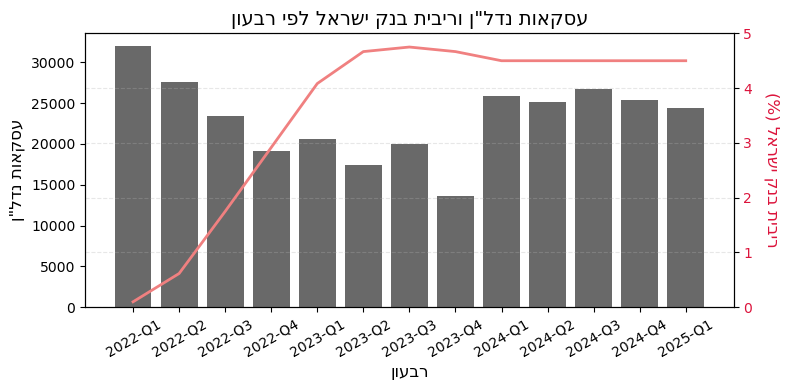

In [4]:


fig, ax1 = plt.subplots(figsize=(8, 4))

left_col = 'dimgrey'
darker_left_col = 'black'

right_col = 'crimson'
gentel_righ_col = 'lightcoral'

# ציר שמאלי - עסקאות נדל"ן
ax1.bar(quarterly_df['year_quarter'], quarterly_df['tus'], color=left_col)
xlab = 'Quarter'
heb_xlab = 'רבעון'
ax1.set_xlabel(heb_xlab[::-1], fontsize=12)  # Reversing the Hebrew label
# ax1.set_xlabel('Quarter', fontsize=12)
ylab0 = 'Units Sold'
heb_ylab0 = 'עסקאות נדל"ן'
ax1.set_ylabel(heb_ylab0[::-1], fontsize=12, color=darker_left_col)  # Reversing the Hebrew label
# ax1.set_ylabel(ylab0, fontsize=12, color=darker_left_col)
ax1.tick_params(axis='y', labelcolor=darker_left_col)
ax1.set_xticklabels(quarterly_df['year_quarter'], rotation=30)

# ציר ימני - ריבית בנק ישראל
ax2 = ax1.twinx()
ax2.plot(quarterly_df['year_quarter'], quarterly_df['boi_interest_rate'], color=gentel_righ_col, linewidth=2, label='Interest Rate')
ylab = 'BOI Interest Rate (%)'
heb_ylab = 'ריבית בנק ישראל )%('
ax2.set_ylabel(heb_ylab[::-1], fontsize=12, color=right_col, rotation=270, labelpad=20)
# ax2.set_ylabel(ylab, fontsize=12, color=right_col, rotation=270, labelpad=20)
ax2.tick_params(axis='y', labelcolor=right_col)
ax2.set_ylim(0, 5)  # Adjust y-axis limits for interest rate

tit = 'Real Estate Transactions and Interest Rate Per Quarter'
heb_tit = 'עסקאות נדל"ן וריבית בנק ישראל לפי רבעון'
plt.title(heb_tit[::-1], fontsize=14)
fig.tight_layout()
plt.grid(True, which='major', linestyle='--', alpha=0.3)
#
plt.show()

####  שוק מתקרר ---> שוק דירות חדשות מתחמם

In [5]:
mydata = nadlan_df[['year_month', 'year_quarter', 'year', 'month', 'quarter',
       'boi_interest_rate','unsold_units_supply',
         'nus', 'ous',       'jerusalem_nus', 'jerusalem_ous',
         'north_nus', 'north_ous',
        'haifa_nus', 'haifa_ous',
       'central_nus', 'central_ous',
        'tlv_nus','tlv_ous',
        'south_nus', 'south_ous',
       'judea_samaria_nus', 'judea_samaria_ous']].copy()

id_vars = ['year_month', 'year_quarter', 'year', 'month', 'quarter', 
           'boi_interest_rate', 'unsold_units_supply']

value_vars = [
    'jerusalem_nus', 'jerusalem_ous',
    'north_nus', 'north_ous',
    'haifa_nus', 'haifa_ous',
    'central_nus', 'central_ous',
    'tlv_nus', 'tlv_ous',
    'south_nus', 'south_ous',
    'judea_samaria_nus', 'judea_samaria_ous'
]

# Step 2: Melt the dataframe
long_df = mydata.melt(id_vars=id_vars, value_vars=value_vars,
                         var_name='region_type', value_name='transactions')

# Step 3: Split region and type
long_df[['region', 'transaction_type']] = long_df['region_type'].str.rsplit('_', n=1, expand=True)

# Step 4: Drop the original 'region_type' column
long_df = long_df.drop(columns='region_type')

# Optional: Reorder columns
long_df = long_df[['year_month', 'year_quarter', 'year', 'month', 'quarter',
                   'boi_interest_rate', 'unsold_units_supply',
                   'region', 'transaction_type', 'transactions']]

long_df['transaction_type'] = long_df['transaction_type'].map({'nus': 'new', 'ous': 'second-hand'})


In [64]:
def get_monthly_summary(data: pd.DataFrame, region: str, year: int) -> pd.DataFrame:
    """
    Return a 12-row DataFrame for the given region and year,
    with columns: month, new (transactions), second_hand (transactions).
    
    Parameters:
        data (pd.DataFrame): Long-format DataFrame.
        region (str): Region name (e.g., 'jerusalem').
        year (int): Year (e.g., 2024).
        
    Returns:
        pd.DataFrame: 12-row DataFrame with columns: month, new, second_hand
    """
    if region == 'all':
        # אם בחרנו את כל האזורים, נחזיר את סיכום כל האזורים
        df = data[data['year'] == year][['month', 'transactions', 'transaction_type']
        ]
    else:
        # סינון רלוונטי
        df = data[(data['region'] == region) & (data['year'] == year)][
            ['month', 'transactions', 'transaction_type']
        ]

    # אגרגציה לפי חודש וסוג עסקה
    pivot_df = df.pivot_table(index='month', 
                              columns='transaction_type', 
                              values='transactions', 
                              aggfunc='sum').reset_index()

    # שינוי שמות עמודות לנוחות
    pivot_df.columns.name = None
    pivot_df = pivot_df.rename(columns={'new': 'new', 'second-hand': 'second_hand'})

    # לוודא שכל 12 החודשים קיימים
    full_months = pd.DataFrame({'month': range(1, 13)})
    result = pd.merge(full_months, pivot_df, on='month', how='left')

    return result

def plot_monthly_rose(data: pd.DataFrame, region: str, title: str, year: int, legend=True, titlesize=14,datesize=9):
    """
    Plot a stacked polar bar chart of monthly transactions (new + second-hand)
    for a specific region and year, with total values labeled above each month.
    """

    # קבלת טבלה מסוכמת עם new + second_hand
    df = get_monthly_summary(data, region, year).fillna(0)

    if region == 'all':
            df_overyears = data.groupby(['year', 'month'])['transactions'].sum().reset_index()

    else:

        df_overyears = data[data['region'] == region].groupby(['year', 'month'])['transactions'].sum().reset_index()
    
    df['total'] = df['new'] + df['second_hand']

    # הדפסת טבלה
    # print(f"\nMonthly transaction breakdown for {region.capitalize()} in {year}:")
    # print(df)

    # זוויות
    angles = np.linspace(0, 2 * np.pi, 12, endpoint=False)
    width = 2 * np.pi / 12
    angles = angles + np.pi / 12  # סיבוב של 30° כך ש-Dec למעלה

    # ערכים
    old_vals = df['second_hand'].values
    new_vals = df['new'].values
    total_vals = df['total'].values

    # ציור גרף
    fig = plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)

    # שכבת עסקאות יד שניה (תחתונה)
    ax.bar(angles, old_vals, width=width, color='darkgrey', edgecolor='white', linewidth=0.8, label='הינש-די תוריד')

    # שכבת עסקאות חדשות (מוערמת על הישנות)
    ax.bar(angles, new_vals, width=width, bottom=old_vals, color='darkslategrey', edgecolor='white', linewidth=0.8, label='תושדח תוריד')



    #========================================================

    # תוויות אחוזים בתוך כל סלייס
    for angle, new_val, old_val in zip(angles, new_vals, old_vals):
        total = new_val + old_val
        if total == 0:
            continue
    # חישוב אחוזים
        pct_new = int(round(100 * new_val / total))
        pct_old = 100 - pct_new

    # טקסט בתוך הסלייס החדש (תכלת)
        if new_val > 0:
            ax.text(angle, old_val + new_val / 2, f"{pct_new}%", 
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')

        # טקסט בתוך הסלייס הישן (אדום)
        # if old_val > 0:
        #     ax.text(angle, old_val / 2, f"{pct_old}%", 
        #             ha='center', va='center', fontsize=7, color='white')
        
    #========================================================


    # תוויות חודשים
    if year == 2022:
        month_labels = ['01-22', '02-22', '03-22', '04-22', '05-22', '06-22',
                        '07-22', '08-22', '09-22', '10-22', '11-22', '12-22']
    elif year == 2023:
        month_labels = ['01-23', '02-23', '03-23', '04-23', '05-23', '06-23',
                        '07-23', '08-23', '09-23', '10-23', '11-23', '12-23']
        
    elif year == 2024:
        month_labels = ['01-24', '02-24', '03-24', '04-24', '05-24', '06-24',
                        '07-24', '08-24', '09-24', '10-24', '11-24', '12-24']
    
    ax.set_xticks(angles)
    ax.set_xticklabels(month_labels, fontsize=datesize, fontweight='bold')
    ax.set_ylim(0, 1.25*df_overyears['transactions'].max())  # Adjust y-axis limit for better visibility

    # תוויות מספריות – טוטאל
    for angle, value in zip(angles, total_vals):
        ax.text(angle, value + (0.075 * max(total_vals)), str(round(float(value/1000),2)),
                ha='center', va='bottom', fontsize=9, color='black')

    # עיצוב
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_yticklabels([])
    ax.spines['polar'].set_visible(False)
    ax.grid(False)

    ax.set_title(f"{title[::-1]}", fontsize=titlesize, pad=40)

    # ax.set_title(f"{region.capitalize()} Transactions by Month ({year})", fontsize=14, pad=30)

    if legend:
        ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.075), fontsize=13)

        plt.tight_layout()
        plt.show()
    else:
        plt.tight_layout()
        plt.show()

def get_monthly_summary_plus(data: pd.DataFrame, region: str, year: int) -> pd.DataFrame:
    """
    Return a 12-row DataFrame for the given region and year,
    with columns: month, new (transactions), second_hand (transactions).
    
    Parameters:
        data (pd.DataFrame): Long-format DataFrame.
        region (str): Region name (e.g., 'jerusalem').
        year (int): Year (e.g., 2024).
        
    Returns:
        pd.DataFrame: 12-row DataFrame with columns: month, new, second_hand
    """

    if region == 'all':
    # אם בחרנו את כל האזורים, נחזיר את סיכום כל האזורים
        df = data[(data['year'] >= year)][
            ['year','month', 'transactions', 'transaction_type']
        ]
    else:
    # סינון רלוונטי
        df = data[(data['region'] == region) & (data['year'] >= year)][
            ['year','month', 'transactions', 'transaction_type']
        ]

    # סינון רלוונטי

    # אגרגציה לפי חודש וסוג עסקה
    pivot_df = df.pivot_table(index=['year','month'], 
                              columns='transaction_type', 
                              values='transactions', 
                              aggfunc='sum').reset_index()

    # שינוי שמות עמודות לנוחות
    pivot_df.columns.name = None
    pivot_df = pivot_df.rename(columns={'new': 'new', 'second-hand': 'second_hand'})
    pivot_df['year_month'] = pivot_df['year'].astype(str) + '-' + pivot_df['month'].astype(str).str.zfill(2)

    # לוודא שכל 12 החודשים קיימים
    # full_months = pd.DataFrame({'year_month': range(1, 16)})
    # result = pd.merge(full_months, pivot_df, on='year_month', how='left')

    return pivot_df

def plot_monthly_rose2(data: pd.DataFrame, region: str, title: str):
    """
    Plot a stacked polar bar chart of monthly transactions (new + second-hand)
    for a specific region and year, with total values labeled above each month.
    """

    # קבלת טבלה מסוכמת עם new + second_hand
    df = get_monthly_summary_plus(data, region, 2024).fillna(0)
    df = df.iloc[4:][['year_month', 'new', 'second_hand']]

    if region == 'all':
        df_overyears = data.groupby(['year', 'month'])['transactions'].sum().reset_index()

    else:

        df_overyears = data[data['region'] == region].groupby(['year', 'month'])['transactions'].sum().reset_index()

    
    df['total'] = df['new'] + df['second_hand']

    # הדפסת טבלה
    # print(f"\nMonthly transaction breakdown for {region.capitalize()} in {year}:")
    # print(df)

    # זוויות
    angles = np.linspace(0, 2 * np.pi, 12, endpoint=False)
    width = 2 * np.pi / 12
    angles = angles + np.pi / 12  # סיבוב של 30° כך ש-Dec למעלה

    # ערכים
    old_vals = df['second_hand'].values
    new_vals = df['new'].values
    total_vals = df['total'].values

    # ציור גרף
    fig = plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)

    # שכבת עסקאות יד שניה (תחתונה)
    ax.bar(angles, old_vals, width=width, color='darkgrey', edgecolor='white', linewidth=0.8, label='הינש די תוריד')

    # שכבת עסקאות חדשות (מוערמת על הישנות)
    ax.bar(angles, new_vals, width=width, bottom=old_vals, color='darkslategrey', edgecolor='white', linewidth=0.8, label='תושדח תוריד')



    #========================================================

    # תוויות אחוזים בתוך כל סלייס
    for angle, new_val, old_val in zip(angles, new_vals, old_vals):
        total = new_val + old_val
        if total == 0:
            continue
    # חישוב אחוזים
        pct_new = int(round(100 * new_val / total))
        pct_old = 100 - pct_new

    # טקסט בתוך הסלייס החדש (תכלת)
        if new_val > 0:
            ax.text(angle, old_val + new_val / 2, f"{pct_new}%", 
                    ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')

        # # טקסט בתוך הסלייס הישן (אדום)
        # if old_val > 0:
        #     ax.text(angle, old_val / 2, f"{pct_old}%", 
        #             ha='center', va='center', fontsize=7, color='white')
        
    #========================================================

    # תוויות חודשים
    month_labels = [
                    # '01/24', '02/24', '03/24',
                    # '04-24',
                    '05-24', '06-24',
                    '07-24', '08-24', '09-24',
                    '10-24', '11-24', '12-24',
                    '01-25', '02-25', '03-25',
                    '04-25'
                    ]
    
    ax.set_xticks(angles)
    ax.set_xticklabels(month_labels, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.15*df_overyears['transactions'].max())  # Adjust y-axis limit for better visibility

    # תוויות מספריות – טוטאל
    for angle, value in zip(angles, total_vals):
        ax.text(angle, value + (0.075 * max(total_vals)), str(round(float(value/1000),2)),
                ha='center', va='bottom', fontsize=9, color='black')

    # עיצוב
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_yticklabels([])
    ax.spines['polar'].set_visible(False)
    ax.grid(False)

    ax.set_title(f"{title[::-1]}", fontsize=16, pad=40)

    # ax.set_title(f"{region.capitalize()} Transactions by Month ({year})", fontsize=14, pad=30)
    # ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.125))

    plt.tight_layout()
    plt.show()

In [60]:
# plot_monthly_rose(long_df, region='all', title = 'תרשים 1: מספר עסקאות הנדל"ן בכל חודש בשנת 2202 )באלפים(' , year=2022)
# plot_monthly_rose2(long_df, region='all', title = 'תרשים 2: מספר עסקאות הנדל"ן בכל חודש בשנה החולפת )באלפים(' )

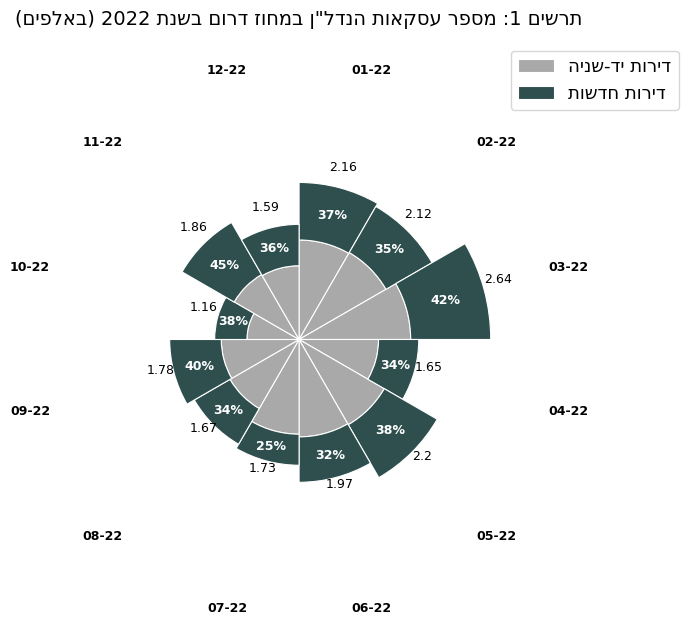

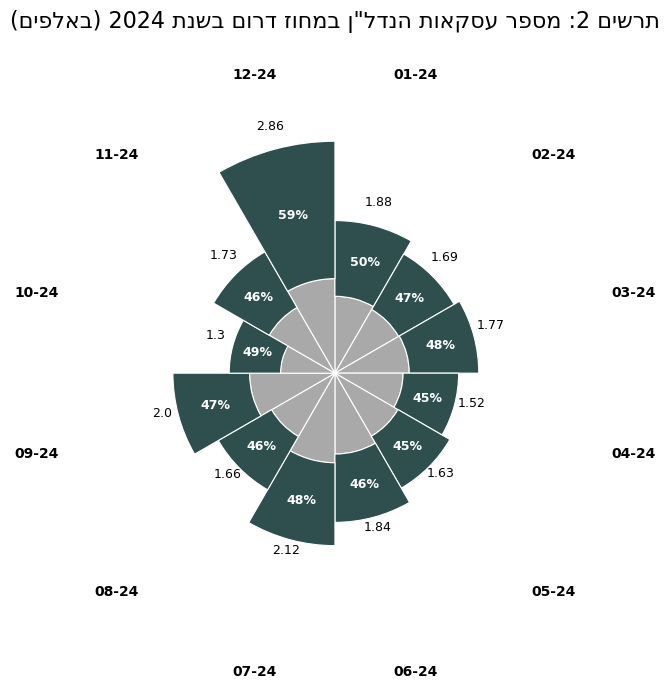

In [65]:
plot_monthly_rose(long_df, region='south', title = 'תרשים 1: מספר עסקאות הנדל"ן במחוז דרום בשנת 2202 )באלפים(' , year=2022)
plot_monthly_rose(long_df, region='south', title = 'תרשים 2: מספר עסקאות הנדל"ן במחוז דרום בשנת 4202 )באלפים(' ,
                   year=2024, legend=False, titlesize=16, datesize=10)


In [48]:
def shares(df, region: str, year: int) -> pd.DataFrame:
    """
    Calculate the share of new and second-hand transactions for a given region and year.
    
    Parameters:
        df (pd.DataFrame): Long-format DataFrame.
        region (str): Region name (e.g., 'south').
        year (int): Year (e.g., 2022).
        
    Returns:
        pd.DataFrame: DataFrame with shares of new and second-hand transactions.
    """

    if region == 'all regions':
        d = df[(df['year'] == year)].groupby(by=['transaction_type'], as_index=False)['transactions'].sum()
    else:    
        d = df[(df['region'] == region) & (df['year'] == year)].groupby(by=['transaction_type'], as_index=False)['transactions'].sum()

    total = d['transactions'].sum()
    share_new = d['transactions'][d['transaction_type'] == 'new'].values[0] / total * 100
    share_second_hand = d['transactions'][d['transaction_type'] == 'second-hand'].values[0] / total * 100

    print(f"Share of new transactions in {region} in {year}: {share_new:.2f}%")
    print(f"Share of second-hand transactions in {region} in {year}: {share_second_hand:.2f}%")
    print("==========="*5)
    

shares(long_df, region='south', year=2022)
shares(long_df, region='south', year=2023)
shares(long_df, region='south', year=2024)
shares(long_df, region='south', year=2025)

print("==========="*5)

shares(long_df, region='north', year=2022)
shares(long_df, region='north', year=2023)
shares(long_df, region='north', year=2024)
shares(long_df, region='north', year=2025)

print("==========="*5)

shares(long_df, region='central', year=2022)
shares(long_df, region='central', year=2023)
shares(long_df, region='central', year=2024)
shares(long_df, region='central', year=2025)


print("==========="*5)

shares(long_df, region='all regions', year=2022)
shares(long_df, region='all regions', year=2023)
shares(long_df, region='all regions', year=2024)
shares(long_df, region='all regions', year=2025)

Share of new transactions in south in 2022: 36.41%
Share of second-hand transactions in south in 2022: 63.59%
Share of new transactions in south in 2023: 44.73%
Share of second-hand transactions in south in 2023: 55.27%
Share of new transactions in south in 2024: 48.55%
Share of second-hand transactions in south in 2024: 51.45%
Share of new transactions in south in 2025: 41.66%
Share of second-hand transactions in south in 2025: 58.34%
Share of new transactions in north in 2022: 30.33%
Share of second-hand transactions in north in 2022: 69.67%
Share of new transactions in north in 2023: 32.34%
Share of second-hand transactions in north in 2023: 67.66%
Share of new transactions in north in 2024: 42.76%
Share of second-hand transactions in north in 2024: 57.24%
Share of new transactions in north in 2025: 34.25%
Share of second-hand transactions in north in 2025: 65.75%
Share of new transactions in central in 2022: 37.86%
Share of second-hand transactions in central in 2022: 62.14%
Share 

#### תרשים 2

In [8]:
df = long_df.groupby(['year','month','year_month', 'transaction_type'])['transactions'].sum().reset_index()
total = df.groupby(['year','month'], as_index=False)['transactions'].sum().rename(columns={'transactions': 'total_transactions'})
df = pd.merge(df, total, on=['year', 'month'], how='left')

df['date'] = pd.to_datetime(df['year_month'].astype(str), format='%Y-%m')

# Pivot for stacked bar
pivot_df = df.pivot_table(index='date',
                          columns='transaction_type',
                          values='transactions',
                          aggfunc='sum').fillna(0)
# Sort by date just in case
pivot_df = pivot_df.sort_index()


In [26]:
# df = df.iloc[6:]
pivot_df

transaction_type,new,second-hand
date,,
2022-01-01,4348,6890
2022-02-01,3410,6770
2022-03-01,4622,7534
2022-04-01,3198,5429
2022-05-01,3799,6436
2022-06-01,3533,6499
2022-07-01,2864,6277
2022-08-01,2743,5218
2022-09-01,2850,5225


In [10]:


new2023 = df[(df['transaction_type'] == 'new') & (df['year'] <2024)]['transactions'].mean()
print(f"{new2023:.0f} new appartments transactions per month in 2023")


old2023 = df[(df['transaction_type'] != 'new') & (df['year'] <2024)]['transactions'].mean()
print(f"{old2023:.0f} old appartments transactions per month in 2023")


new2024 = df[(df['transaction_type'] == 'new') & (df['year'] >=2024)]['transactions'].mean()
print(f"{new2024:.0f} new appartments transactions per month in 2024")

old2024 = df[(df['transaction_type'] != 'new') & (df['year'] >=2024)]['transactions'].mean()
print(f"{old2024:.0f} old appartments transactions per month in 2024")

print(f" rate of change in new appartments transactions from 2023 to 2024: {((new2024 - new2023) / new2023) * 100:.1f}%")
print(f" rate of change in old appartments transactions from 2023 to 2024: {((old2024 - old2023) / old2023) * 100:.1f}%")


# print(f" rate of change in new appartments transactions from 2022-2023 to 2024-2025: {((df[(df['transaction_type'] == 'new') & (df['year'] ==2024)]['transactions'].mean() - df[(df['transaction_type'] == 'new') & (df['year'] <2024)]['transactions'].mean()) / df[(df['transaction_type'] == 'new') & (df['year'] <2024)]['transactions'].mean()) * 100):.1f}%")

2772 new appartments transactions per month in 2023
4714 old appartments transactions per month in 2023
3622 new appartments transactions per month in 2024
4740 old appartments transactions per month in 2024
 rate of change in new appartments transactions from 2023 to 2024: 30.7%
 rate of change in old appartments transactions from 2023 to 2024: 0.6%


In [20]:
nadlan_df.columns

Index(['year_month', 'year_quarter', 'year', 'month', 'quarter',
       'boi_interest_rate', 'tus', 'tus_seasonal_cleaned', 'tus_trend', 'nus',
       'nus_seasonal_cleand', 'nus_trend', 'ous', 'ous_seasonal_cleaned',
       'ous_trend', 'unsold_units_supply', 'uus_seasonal_cleaned', 'uus_trend',
       'jerusalem_tus', 'jerusalem_nus', 'jerusalem_ous', 'north_tus',
       'north_nus', 'north_ous', 'haifa_tus', 'haifa_nus', 'haifa_ous',
       'central_tus', 'central_nus', 'central_ous', 'tlv_tus', 'tlv_nus',
       'tlv_ous', 'south_tus', 'south_nus', 'south_ous', 'judea_samaria_tus',
       'judea_samaria_nus', 'judea_samaria_ous', 'date'],
      dtype='object')

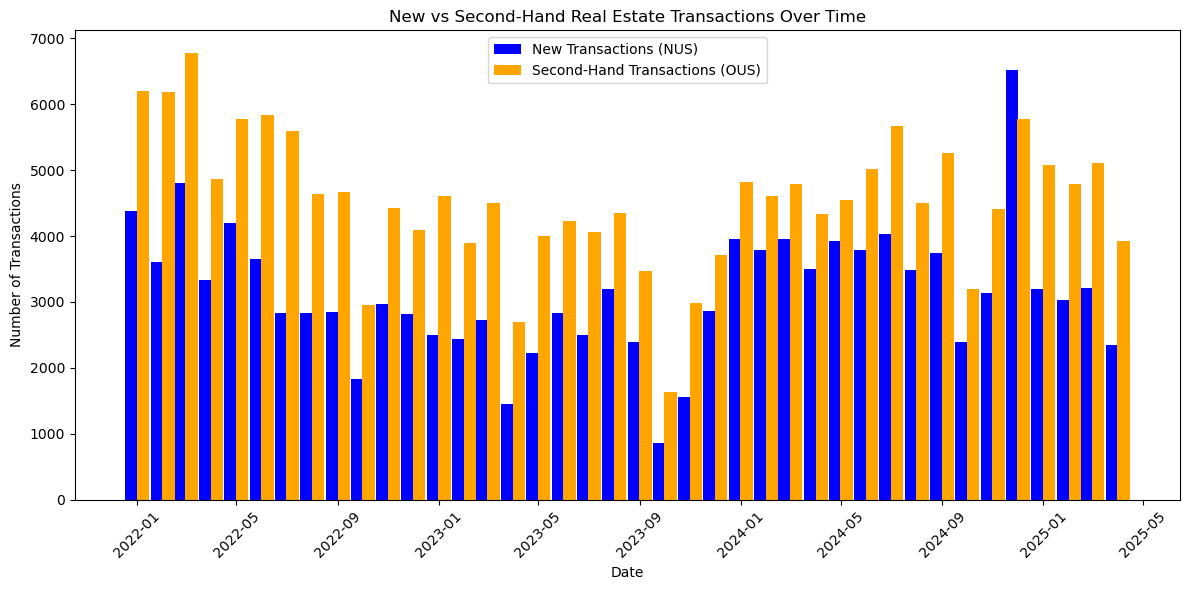

In [25]:

nadlan_df['date'] = pd.to_datetime(nadlan_df['year'].astype(str) + '-' + nadlan_df['month'].astype(str), format='%Y-%m')
nadlan_df['year_month'] = nadlan_df['date'].dt.to_period('M')


# create a plot for 'nus' as new transactions and 'ous' as second-hand transactions not in function and for data=nadlan_df


def plot_nus_ous_bar(nadlan_df):
    fig, ax = plt.subplots(figsize=(12, 6))

    # Width and positions
    width = 15  # days, since x is datetime
    offset = np.timedelta64(7, 'D')  # offset for side-by-side effect

    # Bars for new transactions
    ax.bar(nadlan_df['date'] - offset, nadlan_df['nus'], width=width, label='New Transactions (NUS)', color='blue')

    # Bars for second-hand transactions
    ax.bar(nadlan_df['date'] + offset, nadlan_df['ous'], width=width, label='Second-Hand Transactions (OUS)', color='orange')

    # Labels and styling
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Transactions')
    ax.set_title('New vs Second-Hand Real Estate Transactions Over Time')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Call the function to plot nus and ous
plot_nus_ous_bar(nadlan_df)





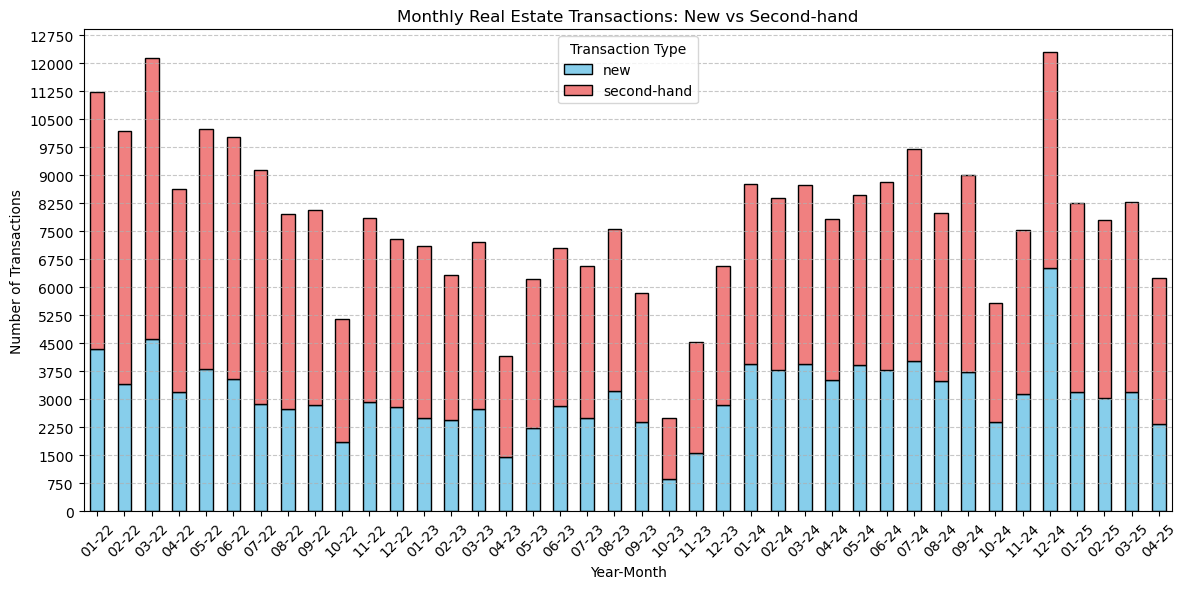

In [27]:
# Plot
# pivot_df = pivot_df.iloc[6:] # Skip the first 5 months for better visibility

# plot
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6),
                   color={'new': 'skyblue', 'second-hand': 'lightcoral'},
                   edgecolor='black')

# format x-axis labels as 'YY-MM'
ax.set_xticklabels([d.strftime('%m-%y') for d in pivot_df.index], rotation=45)

plt.title("Monthly Real Estate Transactions: New vs Second-hand")
plt.xlabel("Year-Month")
plt.ylabel("Number of Transactions")
plt.legend(title="Transaction Type")
plt.tight_layout()
plt.yticks(np.arange(0, pivot_df.sum(axis=1).max() + 1000, 750))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

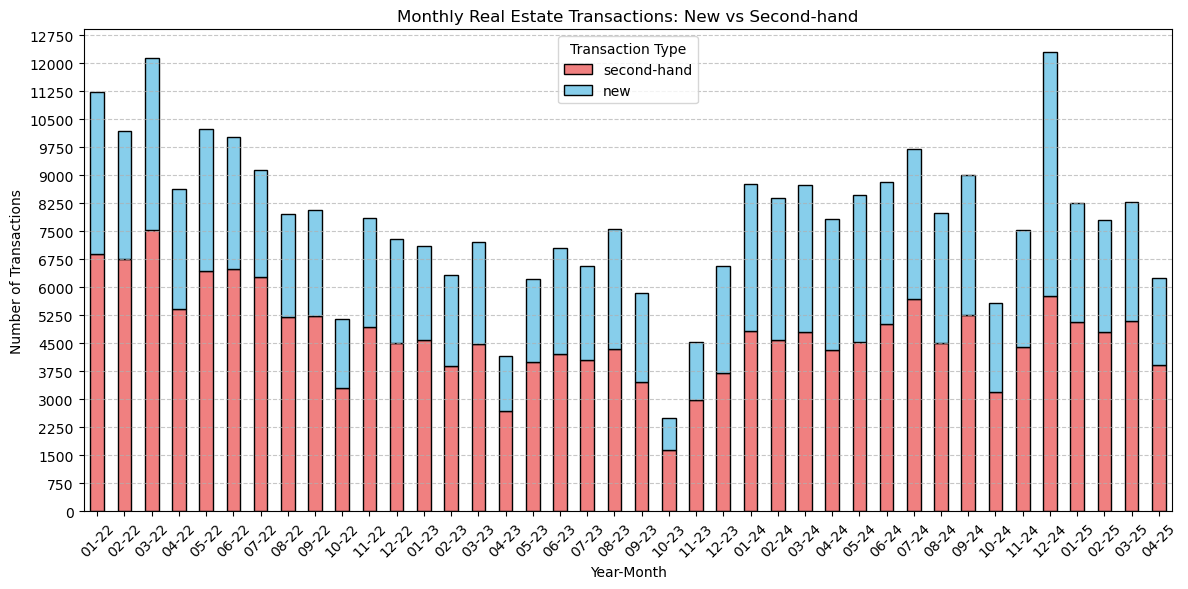

In [28]:
# שינוי סדר העמודות
pivot_df = pivot_df[['second-hand', 'new']]

# ציור גרף
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6),
                   color={'new': 'skyblue', 'second-hand': 'lightcoral'},
                   edgecolor='black')

# תוויות ציר X בפורמט MM-YY
ax.set_xticklabels([d.strftime('%m-%y') for d in pivot_df.index], rotation=45)

plt.title("Monthly Real Estate Transactions: New vs Second-hand")
plt.xlabel("Year-Month")
plt.ylabel("Number of Transactions")
plt.legend(title="Transaction Type")
plt.tight_layout()
plt.yticks(np.arange(0, pivot_df.sum(axis=1).max() + 1000, 750))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

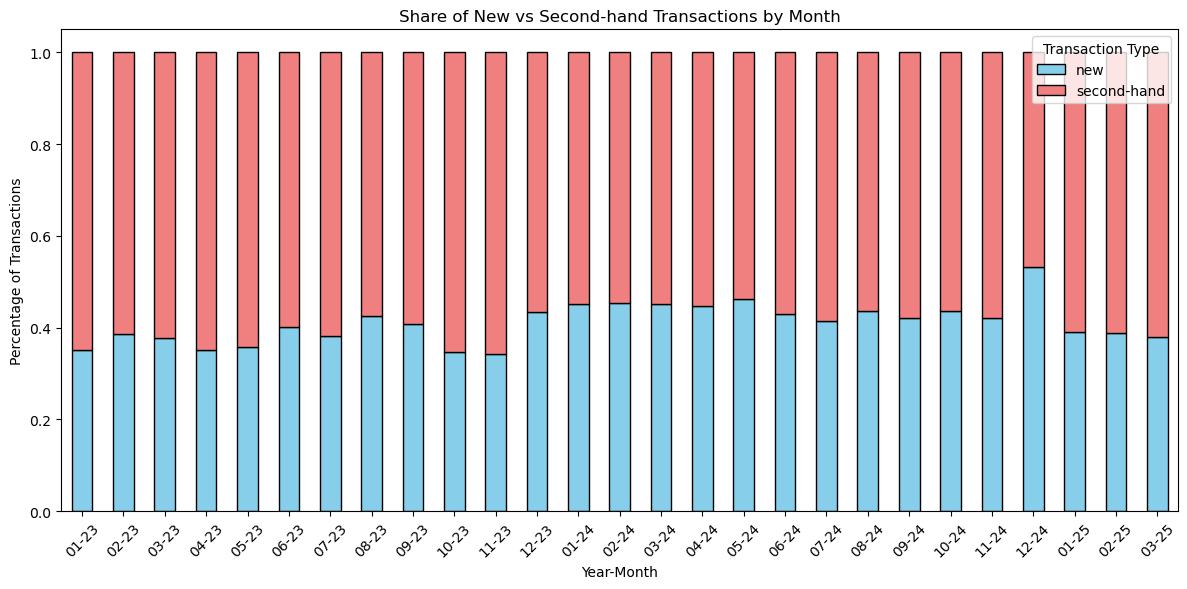

In [38]:
# # שלב 1: יצירת עמודת תאריך
# df['date'] = pd.to_datetime(df['year_month'].astype(str), format='%Y-%m')

# # שלב 2: Pivot – טבלת עסקאות לפי סוג לחודש
# pivot_df = df.pivot_table(index='date',
#                           columns='transaction_type',
#                           values='transactions',
#                           aggfunc='sum').fillna(0).sort_index()

# שלב 3: חישוב אחוזים
percent_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# שלב 4: ציור גרף מוערם באחוזים
ax = percent_df.plot(kind='bar',
                     stacked=True,
                     figsize=(12, 6),
                     color={'new': 'skyblue', 'second-hand': 'lightcoral'},
                     edgecolor='black')

# עיצוב ציר X
ax.set_xticklabels([d.strftime('%m-%y') for d in percent_df.index], rotation=45)

# עיצוב צירים וכותרת
plt.title("Share of New vs Second-hand Transactions by Month")
plt.xlabel("Year-Month")
plt.ylabel("Percentage of Transactions")
plt.legend(title="Transaction Type", loc='upper right')
plt.tight_layout()
plt.show()